# Notebook 07 - Algorithm vs AI Comparison

## Objective
Compare a classical ECG analysis pipeline with the CNN-based classifier.

## Scope
This notebook performs:
- dataset loading
- classical rhythm estimation using R-peak detection and BPM thresholds
- CNN model inference
- side-by-side comparison between classical method and AI model
- agreement analysis
- confusion matrices
- examples of agreement and disagreement

⚠️ This notebook assumes:
- ECG windows are stored in `cnn_X.npy`
- labels are stored in `cnn_y.csv` under `arrhythmia_label`
- trained CNN model is stored in `../models/cnn_ecg_best.keras`


In [54]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

import tensorflow as tf

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

## 1. File paths

In [55]:
X_path = '../data/processed/cnn_X.npy'
y_path = '../data/processed/cnn_y.csv'
model_path = '../models/cnn_ecg_best.keras'
fs = 200  # Hz

print('X exists:', os.path.exists(X_path))
print('y exists:', os.path.exists(y_path))
print('model exists:', os.path.exists(model_path))

X exists: True
y exists: True
model exists: True


In [56]:
if not os.path.exists(X_path):
    raise FileNotFoundError(f'File not found: {X_path}')
if not os.path.exists(y_path):
    raise FileNotFoundError(f'File not found: {y_path}')
if not os.path.exists(model_path):
    raise FileNotFoundError(f'File not found: {model_path}')

X = np.load(X_path)
y_df = pd.read_csv(y_path)
y = y_df['arrhythmia_label'].astype(str).values

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (23005, 3600)
y shape: (23005,)


## 2. Input formatting and normalization

In [57]:
if X.ndim == 2:
    X_raw = X.copy()
    X_model = X[..., np.newaxis]
elif X.ndim == 3:
    X_model = X.copy()
    X_raw = X.squeeze()
else:
    raise ValueError(f'Unsupported X shape: {X.shape}')

X_mean = X_model.mean(axis=1, keepdims=True)
X_std = X_model.std(axis=1, keepdims=True) + 1e-8
X_norm = (X_model - X_mean) / X_std

print('X_raw shape:', X_raw.shape)
print('X_norm shape:', X_norm.shape)

X_raw shape: (23005, 3600)
X_norm shape: (23005, 3600, 1)


## 3. Label encoding for the CNN

In [58]:
label_values = np.unique(y)
label_to_index = {label: idx for idx, label in enumerate(label_values)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

y_enc = np.array([label_to_index[v] for v in y])

print('Classes:', label_values)
print('Mapping:', label_to_index)

Classes: ['fusion' 'normal' 'other' 'supraventricular' 'ventricular']
Mapping: {'fusion': 0, 'normal': 1, 'other': 2, 'supraventricular': 3, 'ventricular': 4}


## 4. Same split used during training

In [59]:
X_train_raw, X_temp_raw, X_train_norm, X_temp_norm, y_train, y_temp = train_test_split(
    X_raw, X_norm, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)

X_val_raw, X_test_raw, X_val_norm, X_test_norm, y_val, y_test = train_test_split(
    X_temp_raw, X_temp_norm, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('Test raw shape:', X_test_raw.shape)
print('Test norm shape:', X_test_norm.shape)
print('Test labels shape:', y_test.shape)

Test raw shape: (3451, 3600)
Test norm shape: (3451, 3600, 1)
Test labels shape: (3451,)


## 5. CNN inference

In [60]:
model = tf.keras.models.load_model(model_path)
y_pred_prob = model.predict(X_test_norm, verbose=0)
y_pred_ai = np.argmax(y_pred_prob, axis=1)

ai_acc = accuracy_score(y_test, y_pred_ai)
print(f'AI accuracy: {ai_acc:.4f}')

AI accuracy: 0.9348


## 6. Classical method: BPM-based rule from detected R-peaks

In [61]:
def bandpass_filter(signal, lowcut=5, highcut=15, fs=200, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def detect_r_peaks_and_bpm(signal, fs=200):
    signal = np.asarray(signal).astype(float).squeeze()

    filtered = bandpass_filter(signal, lowcut=5, highcut=15, fs=fs, order=2)
    derivative = np.gradient(filtered)
    squared = derivative ** 2

    window_ms = 150
    window_samples = max(int((window_ms / 1000) * fs), 1)
    kernel = np.ones(window_samples) / window_samples
    integrated = np.convolve(squared, kernel, mode='same')

    threshold = np.mean(integrated) + 0.5 * np.std(integrated)
    min_distance_samples = int(0.3 * fs)

    peaks, _ = find_peaks(integrated, height=threshold, distance=min_distance_samples)

    if len(peaks) < 2:
        return peaks, 0.0

    rr_intervals_s = np.diff(peaks) / fs
    bpm = np.mean(60 / rr_intervals_s)
    return peaks, bpm

def classical_bpm_label(bpm):
    if bpm == 0:
        return 'unknown'
    elif bpm < 60:
        return 'bradycardia'
    elif bpm > 100:
        return 'tachycardia'
    else:
        return 'normal'

In [62]:
classical_labels = []
classical_bpms = []
classical_peaks = []

for signal in X_test_raw:
    peaks, bpm = detect_r_peaks_and_bpm(signal, fs=fs)
    classical_peaks.append(peaks)
    classical_bpms.append(bpm)
    classical_labels.append(classical_bpm_label(bpm))

classical_labels = np.array(classical_labels)
classical_bpms = np.array(classical_bpms)

print('First classical BPMs:', classical_bpms[:10])
print('First classical labels:', classical_labels[:10])

First classical BPMs: [52.6271003  39.68927871 41.84537446 56.30969636 36.89415268 39.74756264
 28.40160114 32.69852053 31.20266547 44.75964807]
First classical labels: ['bradycardia' 'bradycardia' 'bradycardia' 'bradycardia' 'bradycardia'
 'bradycardia' 'bradycardia' 'bradycardia' 'bradycardia' 'bradycardia']


## 7. Convert AI predictions to textual labels

In [63]:
y_true_labels = np.array([index_to_label[v] for v in y_test])
y_pred_ai_labels = np.array([index_to_label[v] for v in y_pred_ai])

comparison_df = pd.DataFrame({
    'true_label': y_true_labels,
    'ai_label': y_pred_ai_labels,
    'classical_label': classical_labels,
    'classical_bpm': classical_bpms
})

comparison_df.head()

,true_label,ai_label,classical_label,classical_bpm
0,other,other,bradycardia,52.627100
1,normal,normal,bradycardia,39.689279
2,normal,normal,bradycardia,41.845374
3,normal,normal,bradycardia,56.309696
4,normal,normal,bradycardia,36.894153


## 8. Agreement analysis

In [64]:
comparison_df['ai_correct'] = comparison_df['ai_label'] == comparison_df['true_label']
comparison_df['classical_correct'] = comparison_df['classical_label'] == comparison_df['true_label']
comparison_df['ai_vs_classical_agree'] = comparison_df['ai_label'] == comparison_df['classical_label']

comparison_df[['ai_correct', 'classical_correct', 'ai_vs_classical_agree']].mean()

ai_correct               0.934802
classical_correct        0.017386
ai_vs_classical_agree    0.019994
dtype: float64

In [65]:
agreement_summary = pd.DataFrame({
    'Metric': [
        'AI correct rate',
        'Classical correct rate',
        'AI vs Classical agreement rate'
    ],
    'Value': [
        comparison_df['ai_correct'].mean(),
        comparison_df['classical_correct'].mean(),
        comparison_df['ai_vs_classical_agree'].mean()
    ]
})
agreement_summary

,Metric,Value
0,AI correct rate,0.934802
1,Classical correct rate,0.017386
2,AI vs Classical agreement rate,0.019994


## 9. Confusion matrix - AI vs true labels

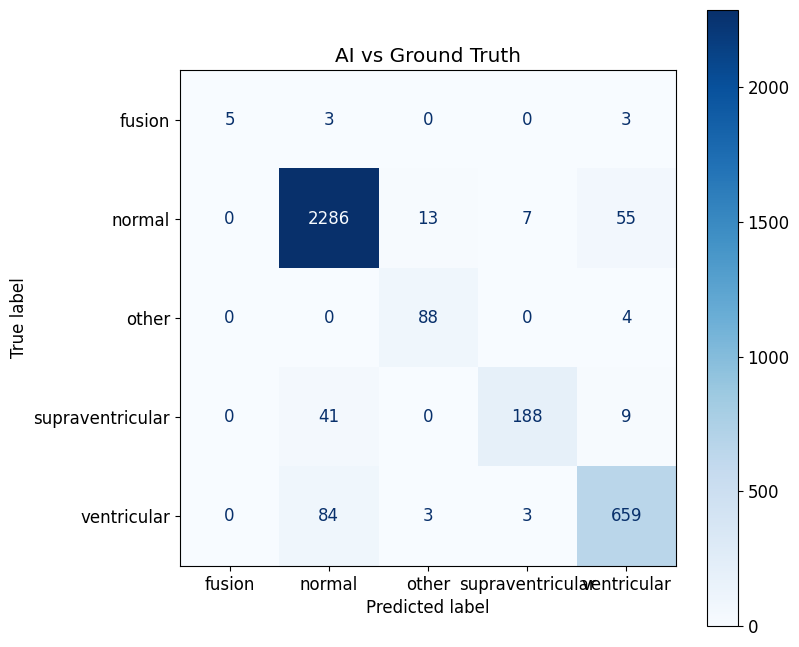

In [66]:
valid_labels = sorted(np.unique(np.concatenate([y_true_labels, y_pred_ai_labels])))
label_order = valid_labels

cm_ai = confusion_matrix(y_true_labels, y_pred_ai_labels, labels=label_order)
disp_ai = ConfusionMatrixDisplay(confusion_matrix=cm_ai, display_labels=label_order)

fig, ax = plt.subplots(figsize=(8, 8))
disp_ai.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('AI vs Ground Truth')
plt.show()

## 10. Confusion matrix - Classical vs true labels

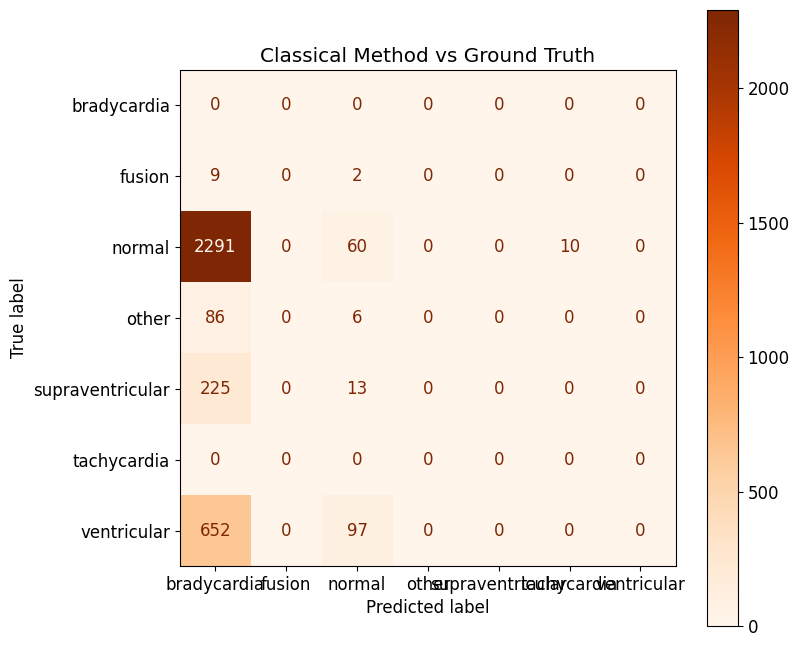

In [67]:
valid_labels_classical = sorted(np.unique(np.concatenate([y_true_labels, classical_labels])))

cm_classical = confusion_matrix(y_true_labels, classical_labels, labels=valid_labels_classical)
disp_classical = ConfusionMatrixDisplay(confusion_matrix=cm_classical, display_labels=valid_labels_classical)

fig, ax = plt.subplots(figsize=(8, 8))
disp_classical.plot(ax=ax, cmap='Oranges', values_format='d')
plt.title('Classical Method vs Ground Truth')
plt.show()

## 11. Agreement and disagreement examples

In [68]:
agree_idx = comparison_df.index[comparison_df['ai_vs_classical_agree']].tolist()
disagree_idx = comparison_df.index[~comparison_df['ai_vs_classical_agree']].tolist()

print('Agreement samples:', len(agree_idx))
print('Disagreement samples:', len(disagree_idx))

Agreement samples: 69
Disagreement samples: 3382


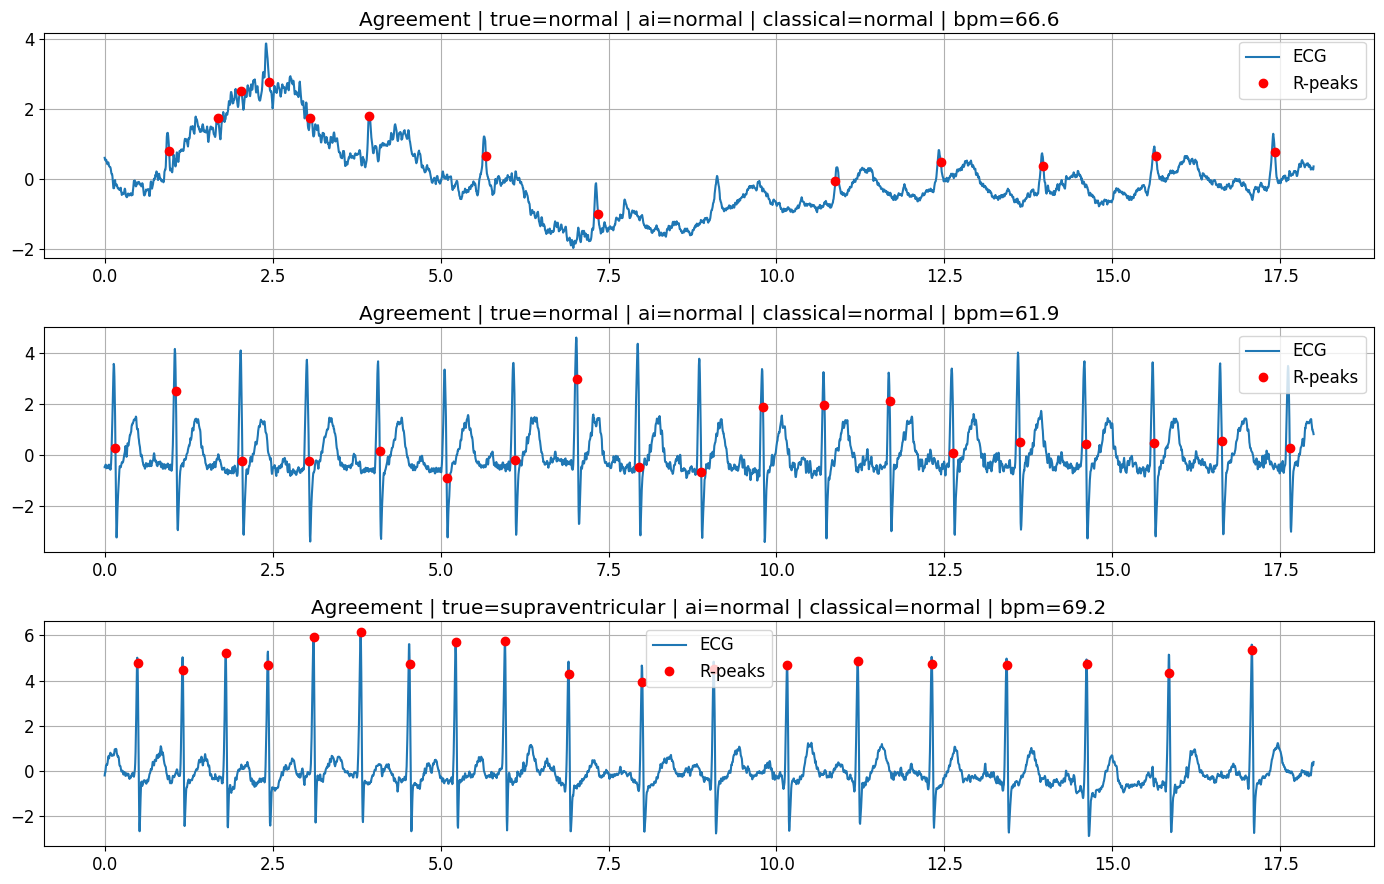

In [69]:
n_show = min(3, len(agree_idx))

if n_show > 0:
    fig, axes = plt.subplots(n_show, 1, figsize=(14, 3 * n_show), sharex=False)
    if n_show == 1:
        axes = [axes]

    for i, idx in enumerate(agree_idx[:n_show]):
        signal = X_test_raw[idx].squeeze()
        peaks = classical_peaks[idx]
        time = np.arange(len(signal)) / fs

        axes[i].plot(time, signal, label='ECG')
        if len(peaks) > 0:
            axes[i].plot(time[peaks], signal[peaks], 'ro', label='R-peaks')
        axes[i].set_title(
            f"Agreement | true={comparison_df.iloc[idx]['true_label']} | "
            f"ai={comparison_df.iloc[idx]['ai_label']} | "
            f"classical={comparison_df.iloc[idx]['classical_label']} | "
            f"bpm={comparison_df.iloc[idx]['classical_bpm']:.1f}"
        )
        axes[i].grid(True)
        axes[i].legend()

    plt.tight_layout()
    plt.show()
else:
    print('No agreement examples to show.')

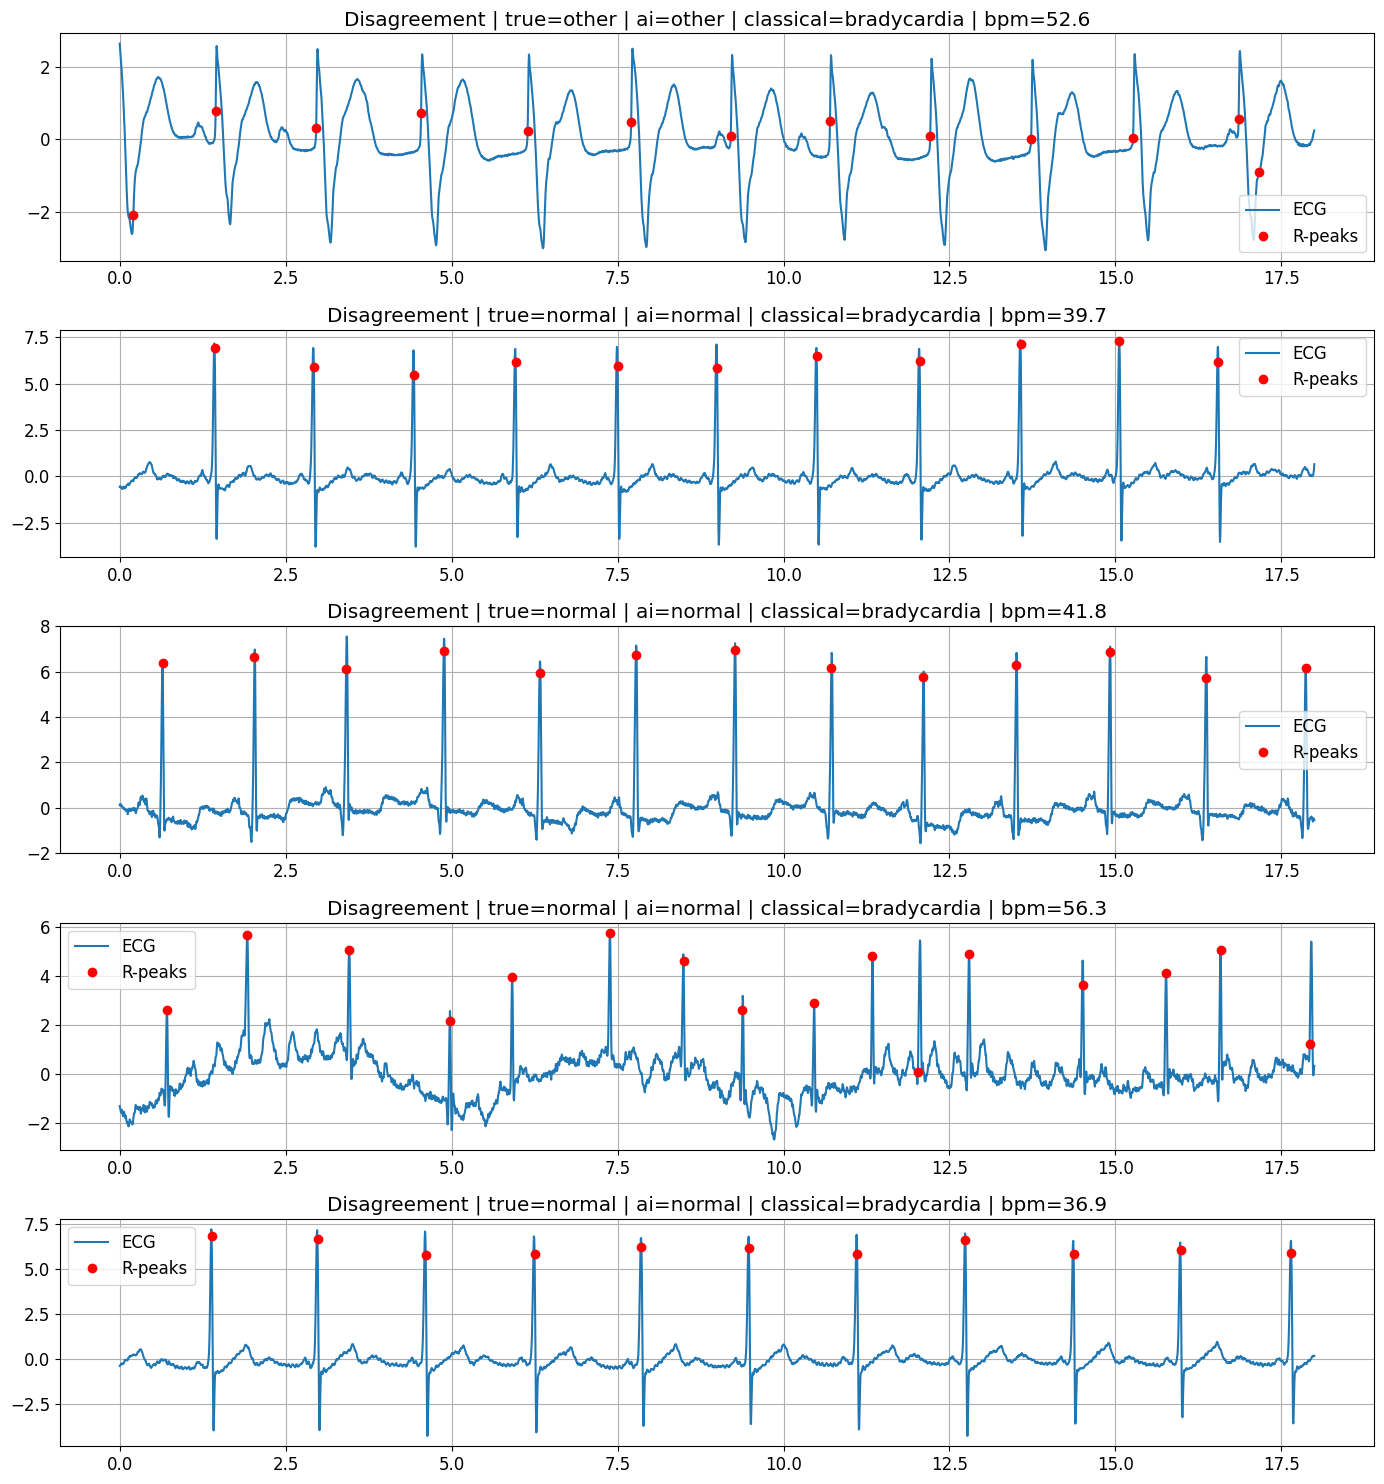

In [70]:
n_show = min(5, len(disagree_idx))

if n_show > 0:
    fig, axes = plt.subplots(n_show, 1, figsize=(14, 3 * n_show), sharex=False)
    if n_show == 1:
        axes = [axes]

    for i, idx in enumerate(disagree_idx[:n_show]):
        signal = X_test_raw[idx].squeeze()
        peaks = classical_peaks[idx]
        time = np.arange(len(signal)) / fs

        axes[i].plot(time, signal, label='ECG')
        if len(peaks) > 0:
            axes[i].plot(time[peaks], signal[peaks], 'ro', label='R-peaks')
        axes[i].set_title(
            f"Disagreement | true={comparison_df.iloc[idx]['true_label']} | "
            f"ai={comparison_df.iloc[idx]['ai_label']} | "
            f"classical={comparison_df.iloc[idx]['classical_label']} | "
            f"bpm={comparison_df.iloc[idx]['classical_bpm']:.1f}"
        )
        axes[i].grid(True)
        axes[i].legend()

    plt.tight_layout()
    plt.show()
else:
    print('No disagreement examples to show.')

## 12. Side-by-side classification reports

In [71]:
print('=== AI classification report ===')
print(classification_report(y_true_labels, y_pred_ai_labels, zero_division=0))

print('=== Classical classification report ===')
print(classification_report(y_true_labels, classical_labels, zero_division=0))

=== AI classification report ===
                  precision    recall  f1-score   support

          fusion       1.00      0.45      0.62        11
          normal       0.95      0.97      0.96      2361
           other       0.85      0.96      0.90        92
supraventricular       0.95      0.79      0.86       238
     ventricular       0.90      0.88      0.89       749

        accuracy                           0.93      3451
       macro avg       0.93      0.81      0.85      3451
    weighted avg       0.94      0.93      0.93      3451

=== Classical classification report ===
                  precision    recall  f1-score   support

     bradycardia       0.00      0.00      0.00         0
          fusion       0.00      0.00      0.00        11
          normal       0.34      0.03      0.05      2361
           other       0.00      0.00      0.00        92
supraventricular       0.00      0.00      0.00       238
     tachycardia       0.00      0.00      0.00      

## 13. Save comparison results

In [72]:
os.makedirs('../reports', exist_ok=True)
comparison_df.to_csv('../reports/algorithm_vs_ai_comparison.csv', index=False)
agreement_summary.to_csv('../reports/algorithm_vs_ai_summary.csv', index=False)

with open('../reports/algorithm_vs_ai_report.txt', 'w', encoding='utf-8') as f:
    f.write('Algorithm vs AI Comparison\n')
    f.write('==========================\n\n')
    f.write(f"AI accuracy: {comparison_df['ai_correct'].mean():.4f}\n")
    f.write(f"Classical accuracy: {comparison_df['classical_correct'].mean():.4f}\n")
    f.write(f"Agreement rate: {comparison_df['ai_vs_classical_agree'].mean():.4f}\n\n")
    f.write('AI report:\n')
    f.write(classification_report(y_true_labels, y_pred_ai_labels, zero_division=0))
    f.write('\nClassical report:\n')
    f.write(classification_report(y_true_labels, classical_labels, zero_division=0))

print('Saved reports to ../reports/')

Saved reports to ../reports/


## 14. Final summary

In [73]:
summary = pd.DataFrame({
    'Metric': [
        'Test samples',
        'AI correct rate',
        'Classical correct rate',
        'Agreement rate',
        'Disagreement samples'
    ],
    'Value': [
        len(comparison_df),
        comparison_df['ai_correct'].mean(),
        comparison_df['classical_correct'].mean(),
        comparison_df['ai_vs_classical_agree'].mean(),
        len(disagree_idx)
    ]
})
summary

,Metric,Value
0,Test samples,3451.000000
1,AI correct rate,0.934802
2,Classical correct rate,0.017386
3,Agreement rate,0.019994
4,Disagreement samples,3382.000000


In [74]:
print('Notebook 07 - Algorithm vs AI Comparison completed successfully.')
print('Generated outputs:')
print('- AI vs ground truth metrics')
print('- Classical method vs ground truth metrics')
print('- agreement/disagreement analysis')
print('- comparison plots')
print('- saved comparison reports in ../reports/')

Notebook 07 - Algorithm vs AI Comparison completed successfully.
Generated outputs:
- AI vs ground truth metrics
- Classical method vs ground truth metrics
- agreement/disagreement analysis
- comparison plots
- saved comparison reports in ../reports/
